# KastRedux Tutorial: Basic Spectral Analysis

## Authors
Adam Burgasser

## Version date
19 July 2022

## Learning Goals
* Read in an optical Kast spectrum (kastredux.getSpectrum)
* Explore built-in functions for Spectrum objects (kastredux.Spectrum)
* Some basic manipulation of spectra - normalizing, scaling, trimming, changing units, spectral math (kastredux.Spectrum)
* Compare a spectrum to another spectrum (kastredux.compareSpectrum)
* Compare a spectrum a set of spectral standards (kastredux.classifyByStandard)
* Measure a set of indices to infer a classification (kastredux.measureIndexSet, kastredux.classifyByIndex)
* Measure line equivalent widths (kastredux.ew, kastredux.ewSet)
* Measure metallicity and magnetic emission (kastredux.zeta, kastredux.lhalbol)

## Keywords
spectral analysis, indices, classification

## Companion Content
None

## Summary
In this tutorial, we will explore some basic spectral analysis and visualization tools included in the kastredux package, which are particularly designed for analysis of ultracol dwarfs (M, L, T dwarfs). 


In [1]:
# if you are using google colab, first install kastredux
#!pip install git+https://github.com/aburgasser/kastredux.git

In [2]:
# import statements
import kastredux as kr
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline




Welcome to the KASTredux reduction package!
This package was developed by Adam Burgasser (aburgasser@ucsd.edu)
You are currently using version 2022.07.19
If you make use of any spectra or models in this package, please remember to cite the original source.
Please report any errors are feature requests to our github page, https://github.com/aburgasser/kastredux/




# Using the kastredux Spectrum object

In this section we'll familiarize ourselves with the kastredux Spectrum object, which contains several built-in functions for basic visualization and spectral manipulation, as well as reading in fits and ascii spectral data

In [3]:
# read in a fits file from sample directory
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J0102+5254_20210925.fits',name='J0101+5254')
sp

KAST red spectrum of J0101+5254

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

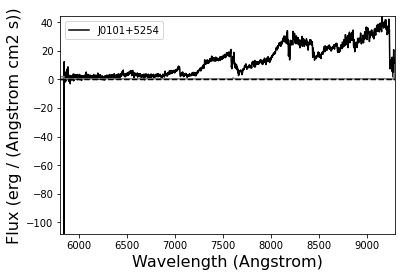

In [4]:
# quick visualization of spectrum
sp.plot()

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

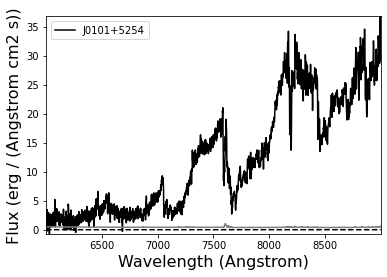

In [5]:
# trim to a smaller spectral region
sp.trim([6000,9000])
sp.plot()

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

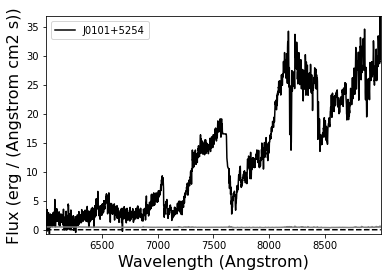

In [6]:
# mask a part of the spectrum, such as telluric absorption regions
sp.maskWave([7580,7640])
sp.plot()

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

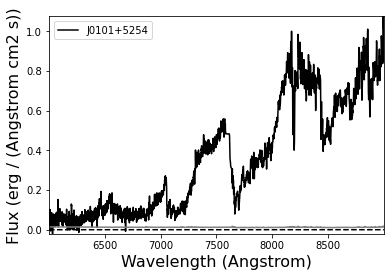

In [7]:
# normalize - notice the difference on the y-axis
sp.normalize([8100,8300])
sp.plot()

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

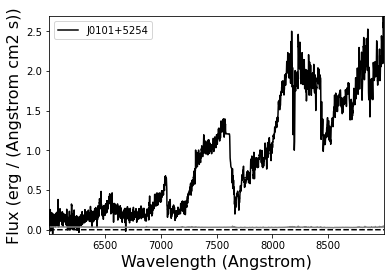

In [8]:
# scale by a constant factor - notice the difference on the y-axis
sp.scale(2.5)
sp.plot()

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

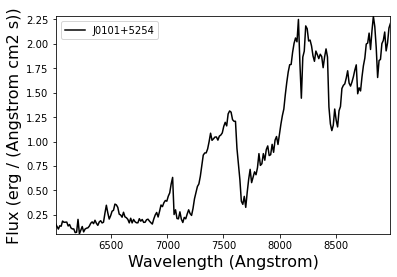

In [9]:
# smooth spectrum
sp.smooth(10)
sp.plot()

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

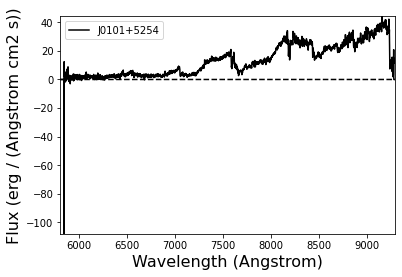

In [10]:
# return to the original spectrum - note: you'll need to add in the name
sp.reset()
sp.name = 'J0101+5254'
sp.plot()

In [11]:
# save spectrum to a file
sp.write('myspectrum.fits')

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

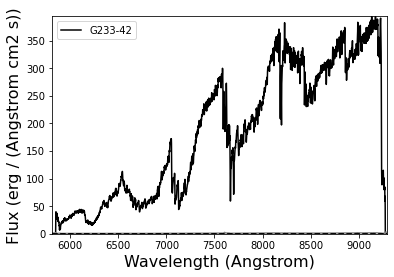

In [12]:
# read in an ascii file from sample directory
sp2 = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_G233-42_20210925.txt',name='G233-42')
sp2.plot()

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

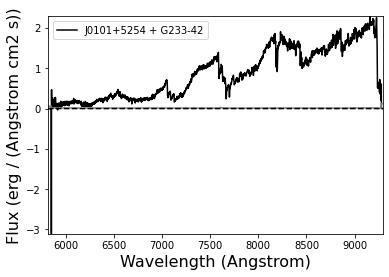

In [13]:
# add two spectra together
sp1 = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J0102+5254_20210925.fits',name='J0101+5254')
sp1.normalize([8100,8300])
sp2 = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_G233-42_20210925.txt',name='G233-42')
sp2.normalize([8100,8300])
sp3 = sp1+sp2
sp3.plot()

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

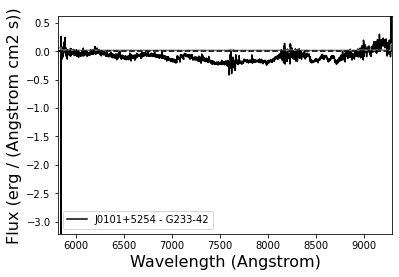

In [14]:
# subtract two spectra
sp3 = sp1-sp2
sp3.plot()

Text(0, 0.5, 'Normalized Flux')

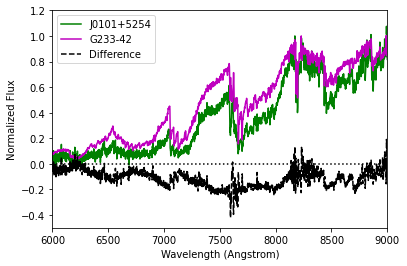

In [15]:
# use matplotlib to compare two spectra and their difference
xlim = [6000,9000]
plt.plot(sp1.wave,sp1.flux,'g-',label=sp1.name)
plt.plot(sp2.wave,sp2.flux,'m-',label=sp2.name)
plt.plot(sp3.wave,sp3.flux,'k--',label='Difference')
plt.legend()
plt.plot(xlim,[0,0],'k:')
plt.xlim(xlim)
plt.ylim([-0.5,1.2])
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Normalized Flux')


# Comparing spectra to each other and standards

One of the most common tasks in spectral analysis is comparing to other spectral templates or models to determine physical properties. kastredux has dedicated tools and comparison spectra for this

158583.38864557864 0.07568977901051262


<Figure size 432x288 with 0 Axes>

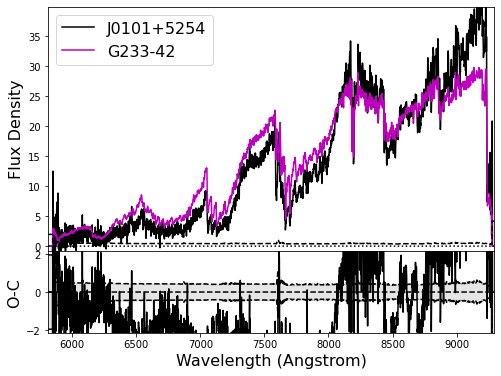

In [16]:
# a common function is to read in 2 spectra and compare them
# note that what is returned is the chi-square statistic and a scale factor for the second spectrum
sp1 = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J0102+5254_20210925.fits',name='J0101+5254')
sp2 = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_G233-42_20210925.txt',name='G233-42')
chi,scale = kr.compareSpectra(sp1,sp2,plot=True)
print(chi,scale)


1292.5427148395931 0.06018121410313681


<Figure size 432x288 with 0 Axes>

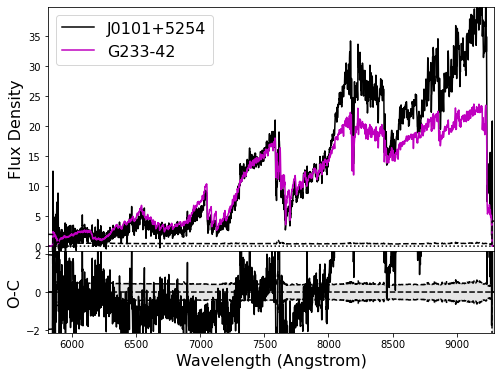

In [17]:
# we can refine te fit but choosing the region to compare
chi,scale = kr.compareSpectra(sp1,sp2,plot=True,fit_range=[7200,7500])
print(chi,scale)

Text(0, 0.5, 'Normalized Flux')

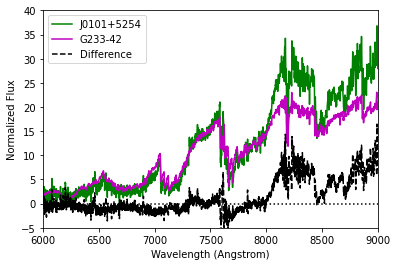

In [18]:
# use the scale factor to generate your own plot using matplotlib
sp2.scale(scale)
sp3 = sp1-sp2

xlim = [6000,9000]
plt.plot(sp1.wave,sp1.flux,'g-',label=sp1.name)
plt.plot(sp2.wave,sp2.flux,'m-',label=sp2.name)
plt.plot(sp3.wave,sp3.flux,'k--',label='Difference')
plt.legend()
plt.plot(xlim,[0,0],'k:')
plt.xlim(xlim)
plt.ylim([-5,40])
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Normalized Flux')


## Comparison to spectral standards

kastredux has a library of built-in spectral standards to compare to spectra to obtain classifications and identify peculiar features

In [19]:
# initialize the spectral standards, which are stored in the SPTSTDS global variable
# by default it will load in M and L dwarf SDSS standards from 
# Bochanski et al., Schmidt et al., and Kesseli et al.
kr.initializeStandards()
kr.SPTSTDS

{'M0.0': KAST red spectrum of M0.0 SDSS STD,
 'M1.0': KAST red spectrum of M1.0 SDSS STD,
 'M2.0': KAST red spectrum of M2.0 SDSS STD,
 'M3.0': KAST red spectrum of M3.0 SDSS STD,
 'M4.0': KAST red spectrum of M4.0 SDSS STD,
 'M5.0': KAST red spectrum of M5.0 SDSS STD,
 'M6.0': KAST red spectrum of M6.0 SDSS STD,
 'M7.0': KAST red spectrum of M7.0 SDSS STD,
 'M8.0': KAST red spectrum of M8.0 SDSS STD,
 'M9.0': KAST red spectrum of M9.0 SDSS STD,
 'L0.0': KAST red spectrum of L0.0 SDSS STD,
 'L1.0': KAST red spectrum of L1.0 SDSS STD,
 'L2.0': KAST red spectrum of L2.0 SDSS STD,
 'L3.0': KAST red spectrum of L3.0 SDSS STD,
 'L4.0': KAST red spectrum of L4.0 SDSS STD,
 'L5.0': KAST red spectrum of L5.0 SDSS STD,
 'L6.0': KAST red spectrum of L6.0 SDSS STD,
 'L7.0': KAST red spectrum of L7.0 SDSS STD,
 'L8.0': KAST red spectrum of L8.0 SDSS STD}

In [20]:
# you can also add in subdwarf (sd, esd, usd), low gravity (beta, gamma), 
# and giant standards from SDSS
kr.initializeStandards(sd=True)
kr.SPTSTDS

{'M0.0': KAST red spectrum of M0.0 SDSS STD,
 'M1.0': KAST red spectrum of M1.0 SDSS STD,
 'M2.0': KAST red spectrum of M2.0 SDSS STD,
 'M3.0': KAST red spectrum of M3.0 SDSS STD,
 'M4.0': KAST red spectrum of M4.0 SDSS STD,
 'M5.0': KAST red spectrum of M5.0 SDSS STD,
 'M6.0': KAST red spectrum of M6.0 SDSS STD,
 'M7.0': KAST red spectrum of M7.0 SDSS STD,
 'M8.0': KAST red spectrum of M8.0 SDSS STD,
 'M9.0': KAST red spectrum of M9.0 SDSS STD,
 'L0.0': KAST red spectrum of L0.0 SDSS STD,
 'L1.0': KAST red spectrum of L1.0 SDSS STD,
 'L2.0': KAST red spectrum of L2.0 SDSS STD,
 'L3.0': KAST red spectrum of L3.0 SDSS STD,
 'L4.0': KAST red spectrum of L4.0 SDSS STD,
 'L5.0': KAST red spectrum of L5.0 SDSS STD,
 'L6.0': KAST red spectrum of L6.0 SDSS STD,
 'L7.0': KAST red spectrum of L7.0 SDSS STD,
 'L8.0': KAST red spectrum of L8.0 SDSS STD,
 'sdM0.0': KAST red spectrum of sdM0.0 LSPMJ0202+0542 STD,
 'sdM1.0': KAST red spectrum of sdM1.0 LSPMJ0938+2200 STD,
 'sdM2.0': KAST red spectru

In [21]:
# you can also add in specific spectral standards from 
# Kirkpatrick et al. (L dwarfs), Burgasser et al. (T dwarfs), and Lepine et al. (subdwarfs)
kr.initializeStandards(sdss=False,reset=True)
kr.SPTSTDS

{'M0.0': KAST red spectrum of M0.0 SDSS STD,
 'M1.0': KAST red spectrum of M1.0 Gl229A STD,
 'M2.0': KAST red spectrum of M2.0 Gl411 STD,
 'M3.0': KAST red spectrum of M3.0 SDSS STD,
 'M4.0': KAST red spectrum of M4.0 Gl402 STD,
 'M5.0': KAST red spectrum of M5.0 SDSS STD,
 'M6.0': KAST red spectrum of M6.0 Teegarden STD,
 'M7.0': KAST red spectrum of M7.0 SDSS STD,
 'M8.0': KAST red spectrum of M8.0 SDSS STD,
 'M9.0': KAST red spectrum of M9.0 SDSS STD,
 'L0.0': KAST red spectrum of L0.0 2MASS0345+2540 STD,
 'L1.0': KAST red spectrum of L1.0 2MASS1439+1929 STD,
 'L2.0': KAST red spectrum of L2.0 2MASS1305-2541 STD,
 'L3.0': KAST red spectrum of L3.0 2MASS1146+2230 STD,
 'L4.0': KAST red spectrum of L4.0 2MASS1155+2307 STD,
 'L5.0': KAST red spectrum of L5.0 2MASS1228-1547 STD,
 'L6.0': KAST red spectrum of L6.0 2MASS0850+1057 STD,
 'L7.0': KAST red spectrum of L7.0 2MASS0205-1159 STD,
 'L8.0': KAST red spectrum of L8.0 2MASS1632+1904 STD,
 'sdM0.0': KAST red spectrum of sdM0.0 LSPMJ02

<AxesSubplot:xlabel='Wavelength (Angstrom)', ylabel='Flux (erg / (Angstrom cm2 s))'>

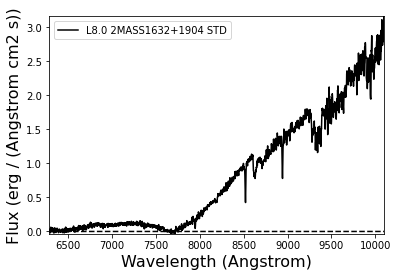

In [22]:
# each of these is just a Spectrum object
kr.SPTSTDS['L8.0'].plot()

'M7.0'

<Figure size 432x288 with 0 Axes>

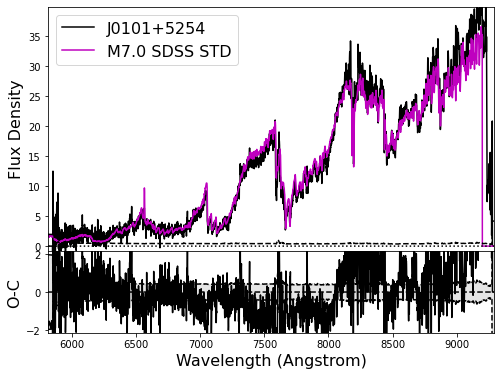

In [23]:
# the easiest way to compare to all sources is to use classifyTemplate()
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J0102+5254_20210925.fits',name='J0101+5254')
kr.classifyTemplate(sp,plot=True)

{'spt': 'M7.0',
 'M0.0': [657210.3780709407, 14.857809692788955],
 'M1.0': [455574.5612357188, 10.469645887465367],
 'M2.0': [439208.6333496637, 9.915953974483815],
 'M3.0': [271135.2953897443, 20.7589017032108],
 'M4.0': [189046.92953237862, 7.248126424989014],
 'M5.0': [121076.18935634263, 23.67514505239869],
 'M6.0': [652865.5904334385, 2.645199719885331],
 'M7.0': [18375.347186511073, 28.669093180073094],
 'M8.0': [27029.864788865234, 34.22124450064231],
 'M9.0': [24542.99267787851, 34.91910599436673],
 'L0.0': [50957.59667046283, 32.03769224659974],
 'L1.0': [119913.74455164072, 32.31271823782471],
 'L2.0': [153680.87706557757, 30.070065738999553],
 'L3.0': [170426.8003311333, 31.228266256077802],
 'L4.0': [262662.97638615064, 30.488350092436622],
 'L5.0': [402812.6586810857, 30.563241507749844],
 'L6.0': [451147.7117935189, 29.285298782113653],
 'L7.0': [515343.87138247734, 28.038361640433838],
 'L8.0': [643663.5064025592, 27.551191894462406],
 'sdM0.0': [542744.4324776819, 15.67

<Figure size 432x288 with 0 Axes>

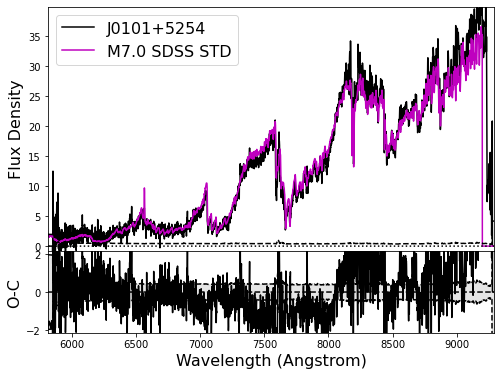

In [24]:
# by default this returns the best fit template; you can also return all of the comparison data
kr.classifyTemplate(sp,plot=True,output='allmeasures')


	G233-42: 368414.43
	J1010+5254: 78216.61
	LP389-13: 3411081.16


'J1010+5254'

<Figure size 432x288 with 0 Axes>

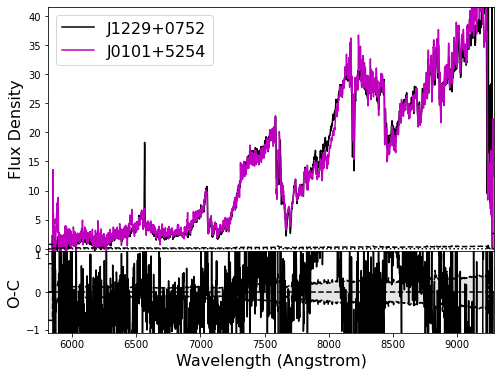

In [25]:
# you can also define a custom template set
templates = {
    'G233-42': kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_G233-42_20210925.txt',name='G233-42'),
    'J1010+5254': kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J0102+5254_20210925.fits',name='J0101+5254'),
    'LP389-13': kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_LP389-13_20210926.fits',name='LP389-13'),
}    
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J1229+0752_20220310.fits',name='J1229+0752')
kr.classifyTemplate(sp,template_set=templates,plot=True,verbose=True)


# Measuring spectral indices

Spectral indices measure the strengths of atomic and molecular features, as well as overall spectral shape, and can be correlated with spectral type or physical quantities such as temperature, surface gravity, and metallicity. kastredux has several sets of pre-defined indices that can be used for optical spectra of ultracool dwarfs.

In [26]:
# the set of index sets included in kastredux 
# are contained in the INDEX_SETS global variable 
kr.INDEX_SETS.keys()

dict_keys(['kirkpatrick1991', 'kirkpatrick1995', 'kirkpatrick1999', 'martin1999', 'gizis1997', 'hawley2002', 'lepine2003', 'reid1995', 'burgasser2003', 'riddick2006', 'stauffer1999', 'slesnick2006'])

In [27]:
kr.INDEX_SETS['lepine2003']['indices'].keys()

dict_keys(['CaH1', 'CaH2', 'CaH3', 'TiO5', 'VO1', 'TiO6', 'VO2', 'TiO7', 'Color-M'])

In [28]:
# you can measure of set of indices using measureIndexSet()
# this returns a dict with each index name key pointed to a value and uncertainty tuple
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J1229+0752_20220310.fits',name='J1229+0752')
kr.measureIndexSet(sp,ref='lepine2003')

/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]


{'CaH1': (0.6613558545215986, 0.005753944040863726),
 'CaH2': (0.23753028658461725, 0.0013208742530987528),
 'CaH3': (0.5022686738444037, 0.0016637850162928105),
 'TiO5': (0.20966902773152732, 0.0012872318256630182),
 'VO1': (0.8370700374738593, 0.001548284465151558),
 'TiO6': (0.4503163288484085, 0.0012776337502108652),
 'VO2': (0.5311666555057839, 0.0008384560698576002),
 'TiO7': (0.687268880471033, 0.001309115369301401),
 'Color-M': (5.7063731969730185, 0.017997100742095064)}

In [29]:
kr.INDEX_SETS

{'kirkpatrick1991': {'altname': ['kirkpatrick91', 'kir91'],
  'bibcode': '1991ApJS...77..417K',
  'indices': {'K91-A': {'ranges': (<Quantity [7020., 7050.] Angstrom>,
     <Quantity [6960., 6990.] Angstrom>),
    'method': 'ratio',
    'sample': 'average'},
   'K91-B': {'ranges': (<Quantity [7375., 7385.] Angstrom>,
     <Quantity [7353., 7363.] Angstrom>),
    'method': 'ratio',
    'sample': 'average'},
   'K91-C': {'ranges': (<Quantity [8100., 8130.] Angstrom>,
     <Quantity [8174., 8204.] Angstrom>),
    'method': 'ratio',
    'sample': 'average'},
   'K91-D': {'ranges': (<Quantity [8567., 8577.] Angstrom>,
     <Quantity [8537., 8547.] Angstrom>),
    'method': 'ratio',
    'sample': 'average'}}},
 'kirkpatrick1995': {'altname': ['kirkpatrick95', 'kir95'],
  'bibcode': '1995AJ....109..797K',
  'indices': {'VO7445': {'ranges': (<Quantity [7350., 7400.] Angstrom>,
     <Quantity [7510., 7560.] Angstrom>,
     <Quantity [7420., 7470.] Angstrom>),
    'scaling': (0.5625, 0.4375, 1.0)

0.2950247553202274 0.002812255961828156


(0.0, 1.2)

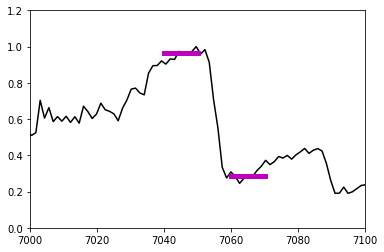

In [30]:
# you can also define your own index by defining the sample ranges
# and the how these are measured and combined
# in this example we'll measure the strength of the TiO band at 8400 Angstroms
# using a simple ratio of in-band value to nearby continuum
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J1229+0752_20220310.fits',name='J1229+0752')
sp.normalize([7000,7100])

rng1 = [7060,7070] # in band
rng2 = [7040,7050] # continuum

val,unc = kr.measureIndex(sp,[[7060,7070],[7045,7055]],sample='median',method='ratio')
print(val,unc)

# visualize this
plt.plot(sp.wave,sp.flux,'k-')
plt.plot(rng1,[sp.sample(rng1),sp.sample(rng1)],'m-',linewidth=5)
plt.plot(rng2,[sp.sample(rng2),sp.sample(rng2)],'m-',linewidth=5)
plt.xlim([7000,7100])
plt.ylim([0,1.2])



## Classifications from indices

Indices can be used to estimate classifications, and it's sometimes useful to compare the template-based classifications to index-based ones

In [31]:
# some of these indices are used for classification
# the global variable INDEX_CLASSIFICATION_RELATIONS contains this info
kr.INDEX_CLASSIFICATION_RELATIONS.keys()

dict_keys(['reid1995', 'gizis1997', 'martin1999', 'martin1999-l', 'lepine2003', 'lepine2003-sd', 'lepine2003-esd', 'lepine2013', 'riddick2007'])

In [32]:
# use the classification indices with kr.classifyIndices()
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J1229+0752_20220310.fits',name='J1229+0752')
kr.classifyIndices(sp,ref='lepine2003',verbose=True)

Using index-SpT relation from lepine2003 (bibcode: 2003AJ....125.1598L)
Remeasuring indices from index sets ['lepine2003']
Remeasuring indices for lepine2003
Index CaH2 = 0.24 rejected as associated spt M6.3 is above spt limit M6.0
Index CaH3 = 0.50 rejected as associated spt M6.8 is above spt limit M6.0


*CaH2 = 0.238+/-0.001 => SpT = M6.3+/-0.3
*CaH3 = 0.502+/-0.001 => SpT = M6.8+/-0.3
TiO5 = 0.210+/-0.001 => SpT = M5.7+/-0.3
VO1 = 0.837+/-0.001 => SpT = M6.7+/-0.3
TiO6 = 0.450+/-0.001 => SpT = M6.9+/-0.3
VO2 = 0.531+/-0.001 => SpT = M6.8+/-0.3
TiO7 = 0.687+/-0.001 => SpT = M6.1+/-0.3
Color-M = 5.706+/-0.017 => SpT = M7.3+/-0.3


/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]


('M6.6', 0.46677390323303686)

'M7.0'

<Figure size 432x288 with 0 Axes>

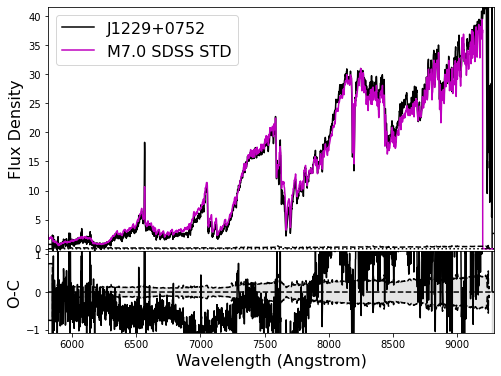

In [33]:
# compare to template classification
kr.classifyTemplate(sp,plot=True)

## Measuring Metallicity

There are also indices used to measure metallicity, based on the zeta method of Lepine et al. (2007). There are several zeta calibrations in kastredux, accessed with the zeta() function, which measures the zeta value and can optionally return the metallicity class and estimate of the metallicity.

In [34]:
# measure zeta 
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J1717+7244_20211113.fits',name='J1717+7244')
kr.zeta(sp,ref='lepine2007')

/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]


(0.8142732194428102, 0.004217133220318812)

In [35]:
# return the metallicity class
kr.zeta(sp,ref='lepine2007',output='class')

'sd'

(684391.3740605712, 9.268574532052416e-15)

<Figure size 432x288 with 0 Axes>

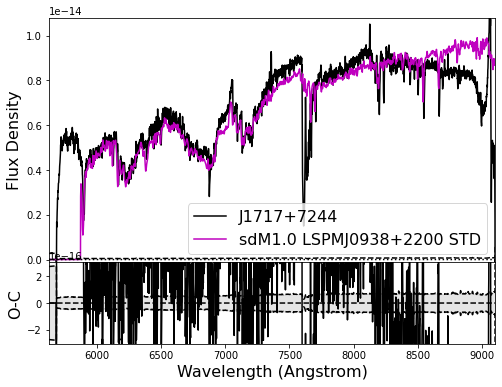

In [36]:
# check against the templates to see if this is right
kr.initializeStandards(sd=True)
kr.compareSpectra(sp,kr.SPTSTDS['sdM1.0'],fit_range=[6000,8500],plot=True)

In [37]:
# return estimate of metallicity from zeta
kr.zeta(sp,ref='lepine2007',metallicity_ref='mann2013',output='z')

/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]


(-0.2240157435020591, 0.20008609292816149)

In [38]:
# return everything
kr.zeta(sp,output='allmeasures')


{'zeta_reference': 'lepine2007',
 'metallicity_reference': 'mann2013',
 'indices': {'CaH1': (0.8781253964649631, 0.0009958661450726314),
  'CaH2': (0.6282486152193745, 0.0008505121665812614),
  'CaH3': (0.831090634915759, 0.0011200193362528941),
  'TiO5': (0.751630310925385, 0.0010716320827167068)},
 'zeta': (0.8142732194428102, 0.004631796541095017),
 'class': 'sd',
 '[Fe/H]': (-0.2240157435020591, 0.2000791637008165)}

# Equivalent Widths

Equivalent widths are measurements of atomic line strengths, equal to the width (in Angstroms) that a perfectly rectangular absorption feature would be if it went to zero flux from the local continuum. Equivalent width is defined as 

$EW = \int\left(1-\frac{F_{line}(\lambda)}{F_{continuum}(\lambda)}\right)d\lambda$

kastredux has several functions for measuring individual lines (measureEW), multiple lines from a given element (measureEWElement), and sets of lines defined in various papers (measureEWSet).


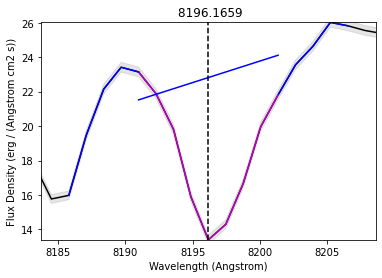

(<Quantity 2.14411325 Angstrom>, <Quantity 0.05156121 Angstrom>)

In [39]:
# measure the EW of the 8195 Angstrom Na I line and visualize measurement
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J1229+0752_20220310.fits',name='J1229+0752')
kr.measureEW(sp,8195,plot=True)


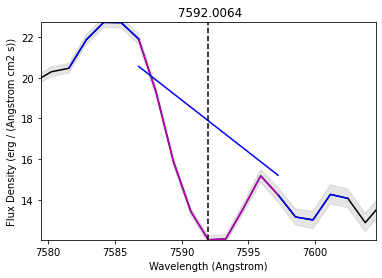

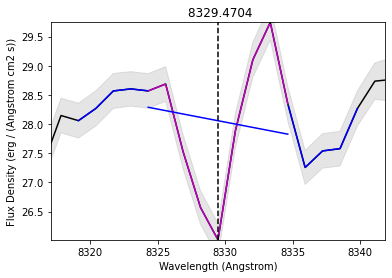

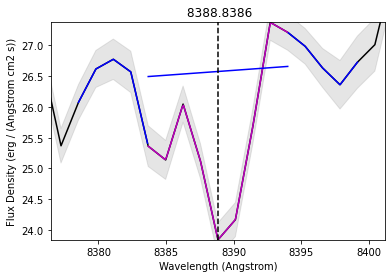

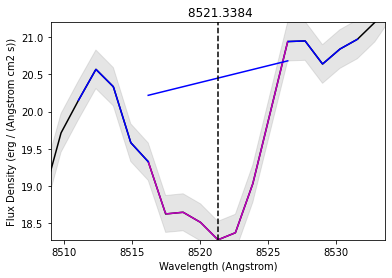

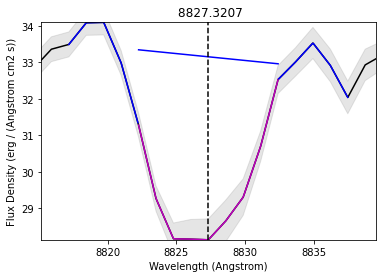

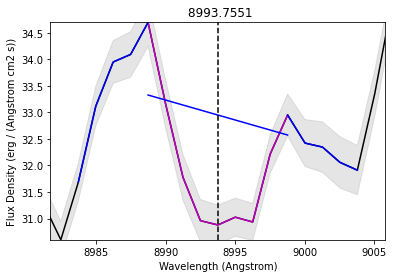

{'FeI-7583': (<Quantity 1.72877566 Angstrom>, <Quantity 0.09780369 Angstrom>),
 'FeI-8327': (<Quantity 0.02067613 Angstrom>, <Quantity 0.04653531 Angstrom>),
 'FeI-8388': (<Quantity 0.43492047 Angstrom>, <Quantity 0.06480907 Angstrom>),
 'FeI-8514': (<Quantity 0.75536563 Angstrom>, <Quantity 0.08333559 Angstrom>),
 'FeI-8824': (<Quantity 1.17876396 Angstrom>, <Quantity 0.08321779 Angstrom>),
 'FeI-9000': (<Quantity 0.33653465 Angstrom>, <Quantity 0.41605292 Angstrom>)}

In [40]:
# measure all of the Fe I lines in a spectrum
kr.measureEWElement(sp,'FeI',plot=True)


Wavelength 4861.0 Angstrom is outside spectral data limits of 5811.006375708462 Angstrom to 9290.526275323784 Angstrom


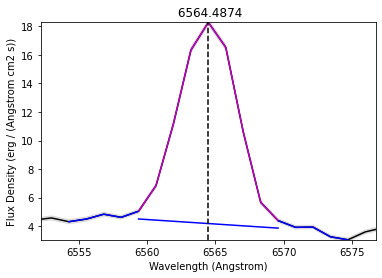

{'HI-4861': (nan, nan),
 'HI-6563': (<Quantity -17.36535486 Angstrom>, <Quantity 0.3353025 Angstrom>)}

In [41]:
# do the same for hydrogen; note for emission lines you 
# should set emission=True and will get a negative EW
kr.measureEWElement(sp,'H',plot=True,emission=True)


In [42]:
# see what lines are currently available for measurement
kr.EW_LINES

{'HI': {'altname': ['H', 'H1', 'H I'],
  'lines': [<Quantity 4861. Angstrom>, <Quantity 6563. Angstrom>]},
 'LiI': {'altname': ['Li', 'Li1', 'Li I'],
  'lines': [<Quantity 6708. Angstrom>]},
 'KI': {'altname': ['K', 'K1', 'K I'],
  'lines': [<Quantity 7665. Angstrom>, <Quantity 7699. Angstrom>]},
 'NaI': {'altname': ['Na', 'Na1', 'Na I'],
  'lines': [<Quantity 8183. Angstrom>, <Quantity 8195. Angstrom>]},
 'CsI': {'altname': ['Cs', 'Cs1', 'Cs I'],
  'lines': [<Quantity 8521. Angstrom>, <Quantity 8943. Angstrom>]},
 'RbI': {'altname': ['Rb', 'Rb1', 'Rb I'],
  'lines': [<Quantity 7800. Angstrom>, <Quantity 7948. Angstrom>]},
 'MgI': {'altname': ['Mg', 'Mg1', 'Mg I'],
  'lines': [<Quantity 8806. Angstrom>]},
 'CaI': {'altname': ['Ca', 'Ca1', 'Ca I'],
  'lines': [<Quantity 6572. Angstrom>,
   <Quantity 7209. Angstrom>,
   <Quantity 7213. Angstrom>,
   <Quantity 7326. Angstrom>]},
 'CaII': {'altname': ['Ca2', 'Ca II'],
  'lines': [<Quantity 8498. Angstrom>,
   <Quantity 8542. Angstrom>,
   

In [43]:
# there is one EW set from the literature included in kastredux from Mann et al. (2013)
kr.measureEWSet(sp,ref='mann2013')

Wavelength 4647.999999999999 Angstrom is outside spectral data limits of 5811.006375708462 Angstrom to 9290.526275323784 Angstrom
Wavelength 5607.999999999998 Angstrom is outside spectral data limits of 5811.006375708462 Angstrom to 9290.526275323784 Angstrom


{'reference': 'Mann et al. (2013)',
 'bibcode': '2013AJ....145...52M',
 'f01': (nan, nan),
 'f02': (nan, nan),
 'f03': (<Quantity 3.99023606 Angstrom>, <Quantity 0.38455378 Angstrom>),
 'f04': (<Quantity 15.44140148 Angstrom>, <Quantity 0.293451 Angstrom>),
 'f05': (<Quantity 8.81820601 Angstrom>, <Quantity 0.34620333 Angstrom>),
 'f06': (<Quantity -1.30855017 Angstrom>, <Quantity 0.06921921 Angstrom>),
 'f07': (<Quantity 5.55309229 Angstrom>, <Quantity 0.06950061 Angstrom>),
 'f08': (<Quantity 0.07508366 Angstrom>, <Quantity 0.06984386 Angstrom>)}

## Measuring Halpha emission and luminosity

The equivalent width of Halpha emission can be used to compute the Halpha luminosity of a star by using a $\chi$ correction that compensates for the local continuum

$\log_{10}\frac{L_{H\alpha}}{L_{bol}} = \chi\times|{EW}|$

There are two empirical relations for the $\chi$ as a function of spectral type contained in kastredux, from Douglas et al. (2014) for spectral types M0-M9 and Schmidt et al. (2014) for spectral types M7-L7, which can be accessed using the chiFactor() function

'M7.0'

<Figure size 432x288 with 0 Axes>

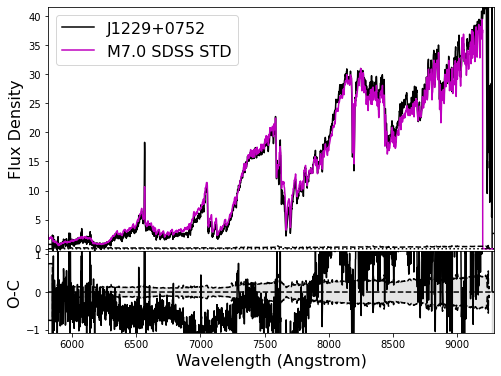

In [44]:
# read in a spectrum and determine its spectal type
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J1229+0752_20220310.fits',name='J1229+0752')
kr.classifyTemplate(sp,plot=True)

In [45]:
# for this M7 dwarf spectrum, we can use either relation; let's try both!
# by default, log(LHalpha/Lbol) that is returned

# Douglas relation
lha,e_lha = kr.chiFactor(sp,ref='douglas2014',verbose=True)
print('log LHa/Lbol = {:.2f}+/-{:.2f}\n'.format(lha,e_lha))

# Schmidt relation
lha,e_lha = kr.chiFactor(sp,ref='schmidt2014',verbose=True)
print('log LHa/Lbol = {:.2f}+/-{:.2f}'.format(lha,e_lha))


Determined a spectral type of 67.0
Measured Halpa equivalent width of 4.45 Angstrom+/-0.50 Angstrom
Determining chi using the douglas2014 relation (bibcode: 2014ApJ...795..161D)
chi = 1.206e-05+/-3.267e-06
LHa/Lbol = 5.364e-05+/-1.567e-05
log LHa/Lbol = -4.27+/-0.13

Determined a spectral type of 67.0
Measured Halpa equivalent width of 4.45 Angstrom+/-0.49 Angstrom
Determining chi using the schmidt2014 relation (bibcode: 2014PASP..126..642S)
chi = 1.028e-05+/-3.130e-06
LHa/Lbol = 4.573e-05+/-1.279e-05
log LHa/Lbol = -4.34+/-0.12


In [46]:
# you can also just get the chi factor and its uncertainty if you want it
kr.chiFactor(sp,ref='douglas2014',output='chi')


(1.2057000000000002e-05, 3.2670000000000002e-06)

# theWorks()

A handy tool that measures everything all at once is theWorks(), which runs through all f the various templates, indices, and relations and returns a large dictionary with a total assessment of the spectrum. Use wisely! Be sure to verify these measurements by visualizing the spectrum

	Template classification = M7.0

Indices:
	kirkpatrick1991
		K91-A: 1.693+/-0.006
		K91-B: 1.090+/-0.002
		K91-C: 1.318+/-0.002
		K91-D: 1.122+/-0.002
	kirkpatrick1995
		VO7445: 1.040+/-0.002


/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]
/Users/adam/python_codes/kastredux/kastredux/core.py:4604: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = value[0]/value[1],value_sim[0,:]/value_sim[1,:]
/Users/adam/python_codes/kastredux/kastredux/core.py:4610: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = (scaling[0]*value[0]+scaling[1]*value[1])/(scaling[2]*value[2]),(scaling[0]*value_sim[0,:]+scaling[1]*value_sim[1,:])/(scaling[2]*value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4610: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = (scaling[0]*value[0]+scaling[1]*value[1])/(scaling[2]*value[2]),(scaling[0]*value_sim[0,:]+scaling[1]*value_sim[1,:])/(scaling[2]*value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4606: RuntimeWarning: divide by z

	kirkpatrick1999
		Rb-a: 1.065+/-0.003
		Rb-b: 1.047+/-0.002
		Na-a: 1.761+/-0.003
		Na-b: 1.952+/-0.004
		Cs-a: 1.131+/-0.002
		Cs-b: 1.034+/-0.002
		TiO-a: 2.687+/-0.009
		TiO-b: 0.589+/-0.001
		VO-a: 1.014+/-0.001
		VO-b: 1.105+/-0.002
		CrH-a: 1.040+/-0.002
		CrH-b: nan+/-nan
		FeH-a: 1.103+/-0.002
		FeH-b: nan+/-nan
		Color-a: nan+/-nan
		Color-b: nan+/-nan
		Color-c: nan+/-nan
		Color-d: nan+/-nan
	martin1999
		PC3: 1.533+/-0.003
		PC6: 7.743+/-0.024
		CrH1: 0.999+/-0.002
		CrH2: nan+/-nan
		FeH1: 1.019+/-0.002
		FeH2: nan+/-nan
		H2O1: inf+/-20837.230
		TiO1: 2.150+/-0.009
		TiO2: 1.409+/-0.003
		VO1: 1.220+/-0.002
		VO2: 1.358+/-0.003


/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in double_scalars
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])
/Users/adam/python_codes/kastredux/kastredux/core.py:4608: RuntimeWarning: divide by zero encountered in true_divide
  val,vals = 2.*value[0]/(value[1]+value[2]),2.*value_sim[0,:]/(value_sim[1,:]+value_sim[2,:])


	gizis1997
		CaH1: 0.661+/-0.007
		CaH2: 0.238+/-0.001
		CaH3: 0.502+/-0.002
		TiO5: 0.210+/-0.001
	hawley2002
		VO-7434: 0.837+/-0.002
		VO-7912: 0.559+/-0.001
		Na-8190: 1.335+/-0.002
		TiO-8440: 0.687+/-0.001
		Color-1: 1.902+/-0.003
	lepine2003
		CaH1: 0.661+/-0.006
		CaH2: 0.238+/-0.001
		CaH3: 0.502+/-0.002
		TiO5: 0.210+/-0.001
		VO1: 0.837+/-0.002
		TiO6: 0.450+/-0.001
		VO2: 0.531+/-0.001
		TiO7: 0.687+/-0.001
		Color-M: 5.706+/-0.018


...

	riddick2006
		R1: 1.253+/-0.006
		R2: 1.500+/-0.009
		R3: 1.368+/-0.005
		R4: 1.654+/-0.005
	stauffer1999
		c81: 1.650+/-0.005
	slesnick2006
		TiO-7140: 3.119+/-0.050
		TiO-8465: 1.567+/-0.006
		Na-8189: 0.738+/-0.004

Index based classifications:
	reid1995: M5.9+/-0.3
	gizis1997: M5.7+/-0.5
	martin1999: M6.5+/-0.1


/Users/adam/python_codes/kastredux/kastredux/core.py:4913: RuntimeWarning: invalid value encountered in double_scalars
  sptn = numpy.nansum(vals[w]*wts[w])/numpy.nansum(wts[w])
/Users/adam/python_codes/kastredux/kastredux/core.py:4914: RuntimeWarning: divide by zero encountered in double_scalars
  sptn_e = (numpy.nanstd(vals[w])**2+1./numpy.nansum(wts[w]))**0.5


	martin1999-l: nan+/-inf
	lepine2003: M6.6+/-0.5
	lepine2003-sd: M5.6+/-0.6
	lepine2003-esd: M5.5+/-3.4
	lepine2013: M5.7+/-4.7
	riddick2007: M5.6+/-0.3

Zeta:
	lepine2007: 0.944+/-0.002 => d
	lepine2013: 0.968+/-0.002 => d
	dhital2012: 0.945+/-0.002 => d
	zhang2019: 0.892+/-0.002 => d

Zeta metallicity for lepine2013:
	lepine2013: -0.02+/-0.38
	lepine2013-ra12: -0.06+/-0.65
	woolf2009: -0.10+/-0.30
	mann2013: -0.03+/-0.20
	mann2013-mh: -0.04+/-0.20

Line EWs:
Wavelength 4861.0 Angstrom is outside spectral data limits of 5811.006375708462 Angstrom to 9290.526275323784 Angstrom
	HI
		HI-4861: nan+/-nan
		HI-6563: 4.45 Angstrom+/-0.59 Angstrom
	LiI
		LiI-6708: 0.32 Angstrom+/-2.20 Angstrom
	KI
		KI-7665: 4.06 Angstrom+/-0.13 Angstrom
		KI-7699: 3.87 Angstrom+/-0.11 Angstrom
	NaI
		NaI-8183: 1.88 Angstrom+/-0.09 Angstrom
		NaI-8195: 2.14 Angstrom+/-0.05 Angstrom
	CsI
		CsI-8521: 0.76 Angstrom+/-0.07 Angstrom
		CsI-8943: 0.63 Angstrom+/-0.06 Angstrom
	RbI
		RbI-7800: 1.03 Angstrom+/-0.08 A

{'spt-template': 'M7.0',
 'indices': {'kirkpatrick1991': {'K91-A': (1.6926641182436803,
    0.005901883749703342),
   'K91-B': (1.0900248162359765, 0.0020971823596031914),
   'K91-C': (1.317534858197542, 0.002196879166967386),
   'K91-D': (1.1221269049439515, 0.0020789832329327247)},
  'kirkpatrick1995': {'VO7445': (1.0402260138959654, 0.001713615122501083)},
  'kirkpatrick1999': {'Rb-a': (1.0651593651897133, 0.0028182638806996453),
   'Rb-b': (1.0468525187383182, 0.001956709506916486),
   'Na-a': (1.7605296313796286, 0.00322041392889035),
   'Na-b': (1.952263612062318, 0.003811903641153762),
   'Cs-a': (1.1310917567222813, 0.0018571577002927321),
   'Cs-b': (1.0339168750494774, 0.0016776003670967584),
   'TiO-a': (2.6865609320320987, 0.008787158277639798),
   'TiO-b': (0.5888625683525889, 0.0011882178563161782),
   'VO-a': (1.014305730721232, 0.0014703343059094015),
   'VO-b': (1.1051913819257704, 0.001674896800893183),
   'CrH-a': (1.0398005350538875, 0.0018807021522345185),
   'CrH-

<Figure size 432x288 with 0 Axes>

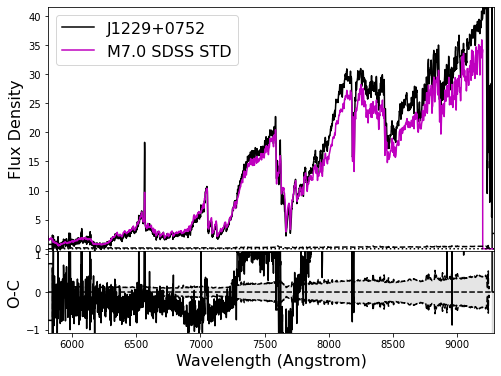

In [47]:
sp = kr.readSpectrum(kr.SAMPLEFOLDER+'kastRED_J1229+0752_20220310.fits',name='J1229+0752')
kr.theWorks(sp,verbose=True)